In [33]:
# Exploratory Data Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("../data/processed/hotel_bookings_clean.csv")

print("Cleaned dataset loaded successfully!")
print("Shape:", df.shape)

Cleaned dataset loaded successfully!
Shape: (87222, 34)


In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_stay_nights,total_previous_bookings
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,0


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87222 entries, 0 to 87221
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87222 non-null  str    
 1   is_canceled                     87222 non-null  int64  
 2   lead_time                       87222 non-null  int64  
 3   arrival_date_year               87222 non-null  int64  
 4   arrival_date_month              87222 non-null  str    
 5   arrival_date_week_number        87222 non-null  int64  
 6   arrival_date_day_of_month       87222 non-null  int64  
 7   stays_in_weekend_nights         87222 non-null  int64  
 8   stays_in_week_nights            87222 non-null  int64  
 9   adults                          87222 non-null  int64  
 10  children                        87222 non-null  int64  
 11  babies                          87222 non-null  int64  
 12  meal                            87222 non-n

In [37]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_stay_nights,total_previous_bookings
count,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000,...,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000,87222.000000
mean,0.275263,79.975545,2016.210360,26.834709,15.816113,1.004632,2.624040,1.879411,0.138910,0.010846,...,0.184048,0.268499,81.090608,0.746360,106.521167,0.084314,0.698964,2.029167,3.628672,0.214453
std,0.446649,86.059240,0.686054,13.668954,8.835618,1.027377,2.039816,0.621716,0.456284,0.113709,...,1.733101,0.710637,109.977150,10.001457,54.889335,0.281670,0.832057,0.790139,2.742888,1.908309
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,9.000000,0.000000,72.250000,0.000000,0.000000,2.000000,2.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,9.000000,0.000000,98.200000,0.000000,0.000000,2.000000,3.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,240.000000,0.000000,134.100000,0.000000,1.000000,2.000000,5.000000,0.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,72.000000,18.000000,535.000000,391.000000,5400.000000,8.000000,5.000000,55.000000,69.000000,78.000000


**1. Overall cancellation rate**

In [ ]:
# 1 --> canceled
# 0 --> not canceled
cancellation_counts = df["is_canceled"].value_counts()

cancellation_counts

is_canceled
0    63213
1    24009
Name: count, dtype: int64

In [39]:
cancellation_rate = df["is_canceled"].mean() * 100

print(f"Overall cancellation rate: {cancellation_rate:.2f}%")

Overall cancellation rate: 27.53%


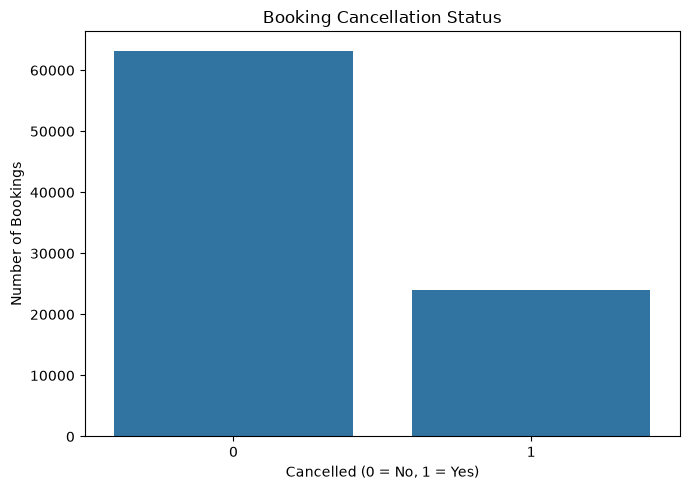

In [57]:
#Visualize overall cancellations
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="is_canceled")

plt.title("Booking Cancellation Status")
plt.xlabel("Cancelled (0 = No, 1 = Yes)")
plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig("../image/booking_cancellation_status.png", dpi=300, bbox_inches="tight")

plt.show()

**2. Cancellation Rate by Hotel**

In [41]:
#Does cancellation behavior differ between City and Resort hotels?

hotel_cancellation = df.groupby("hotel")["is_canceled"].mean() * 100

print(hotel_cancellation.round(2))

hotel
City Hotel      30.10
Resort Hotel    23.49
Name: is_canceled, dtype: float64


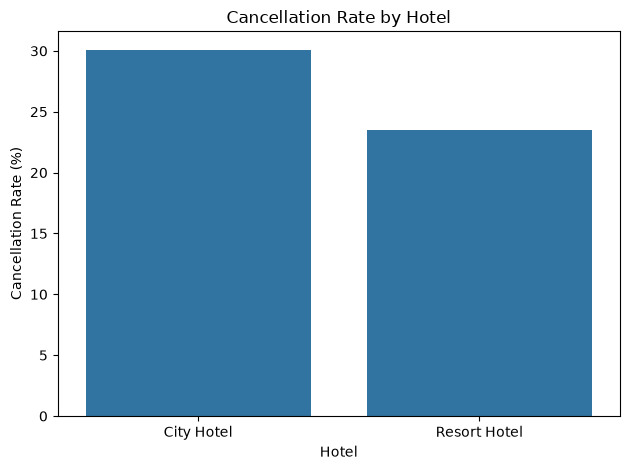

In [68]:
sns.barplot(
    x=hotel_cancellation.index,
    y=hotel_cancellation.values
)

plt.title("Cancellation Rate by Hotel")
plt.xlabel("Hotel")
plt.ylabel("Cancellation Rate (%)")

plt.tight_layout()
plt.savefig("../image/cancellation_by_hotel.png", dpi=300, bbox_inches="tight")
plt.show()

**3. Cancellation by Market Segment**


In [43]:
#Which booking channels/market segments have higher cancellation rates?

segment_cancellation = (
    df.groupby("market_segment")["is_canceled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(segment_cancellation.round(2))

market_segment
Undefined        100.00
Online TA         35.39
Groups            27.07
Aviation          19.91
Offline TA/TO     14.85
Direct            14.75
Complementary     12.28
Corporate         12.13
Name: is_canceled, dtype: float64


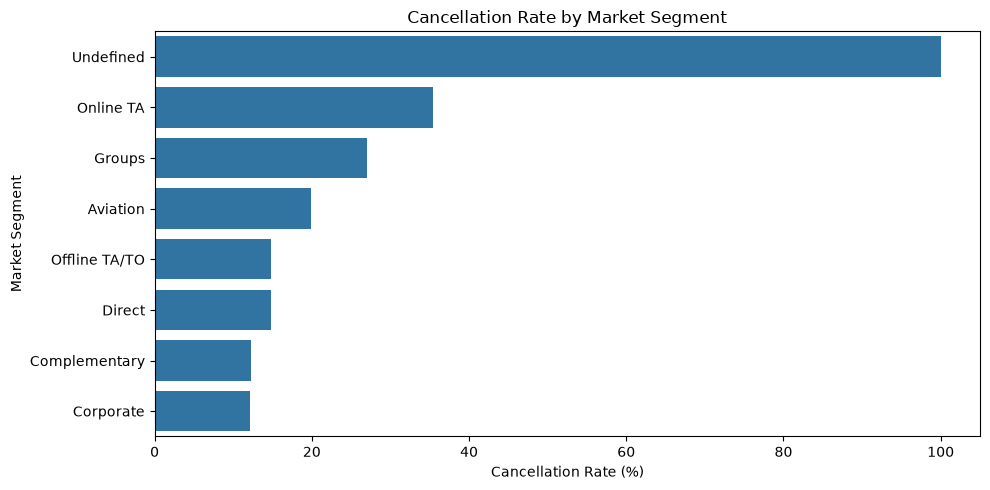

In [67]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=segment_cancellation.values,
    y=segment_cancellation.index
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Market Segment")

plt.tight_layout()
plt.savefig("../image/cancellation_by_market_segment.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
segment_summary = df.groupby("market_segment").agg(
    bookings=("is_canceled", "count"),
    cancellation_rate=("is_canceled", "mean")
)

segment_summary["cancellation_rate"] = (
    segment_summary["cancellation_rate"] * 100
).round(2)

segment_summary = segment_summary.sort_values(
    "cancellation_rate", ascending=False
)

segment_summary

,bookings,cancellation_rate
market_segment,,
Undefined,2,100.00
Online TA,51550,35.39
Groups,4921,27.07
Aviation,226,19.91
Offline TA/TO,13855,14.85
Direct,11780,14.75
Complementary,692,12.28
Corporate,4196,12.13


**4. Lead Time vs Cancellation**

In [46]:
#Do customers who book further in advance cancel more often?

df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, float("inf")],
    labels=["0-7 days", "8-30 days", "31-90 days", "91-180 days", "181+ days"]
)

In [47]:
lead_time_cancellation = (
    df.groupby("lead_time_group", observed=True)["is_canceled"]
    .mean()
    .mul(100)
)

print(lead_time_cancellation.round(2))

lead_time_group
0-7 days        8.42
8-30 days      25.39
31-90 days     32.04
91-180 days    35.01
181+ days      39.74
Name: is_canceled, dtype: float64


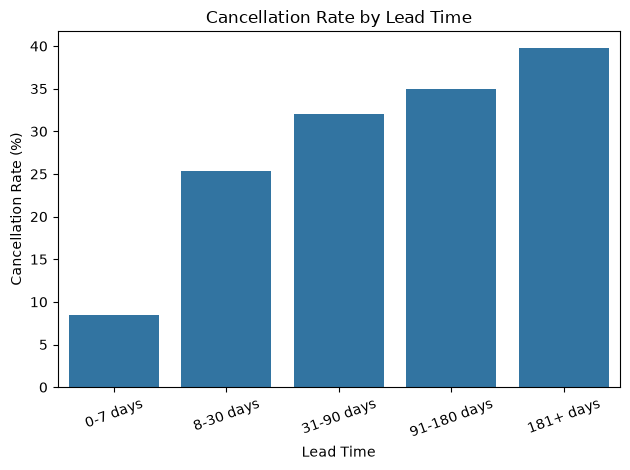

In [66]:
sns.barplot(
    x=lead_time_cancellation.index,
    y=lead_time_cancellation.values
)

plt.title("Cancellation Rate by Lead Time")
plt.xlabel("Lead Time")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../image/cancellation_by_lead_time.png", dpi=300, bbox_inches="tight")
plt.show()

**5. Deposit Type vs Cancellation**


In [49]:
#Does deposit type affect cancellation behavior?

deposit_cancellation = (
    df.groupby("deposit_type")["is_canceled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(deposit_cancellation.round(2))

deposit_type
Non Refund    94.70
No Deposit    26.72
Refundable    24.30
Name: is_canceled, dtype: float64


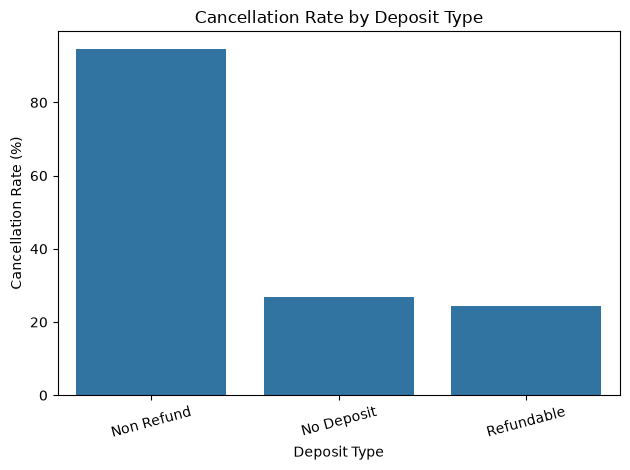

In [65]:
sns.barplot(
    x=deposit_cancellation.index,
    y=deposit_cancellation.values
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("../image/cancellation_by_deposit_type.png", dpi=300, bbox_inches="tight")
plt.show()


**6. Cancellation Trend Over Time**


In [51]:
#How does cancellation behavior change over time?

df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"] + "-" +
    df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d"
)

In [52]:
monthly_cancellation = (
    df.groupby(df["arrival_date"].dt.to_period("M"))["is_canceled"]
    .mean()
    .mul(100)
)

print(monthly_cancellation.round(2))

arrival_date
2015-07    30.62
2015-08    23.33
2015-09    19.94
2015-10    16.33
2015-11    14.64
2015-12    18.84
2016-01    16.28
2016-02    18.79
2016-03    23.16
2016-04    26.89
2016-05    24.91
2016-06    25.92
2016-07    28.33
2016-08    32.66
2016-09    27.97
2016-10    28.44
2016-11    24.43
2016-12    32.05
2017-01    25.95
2017-02    26.99
2017-03    25.75
2017-04    33.70
2017-05    32.87
2017-06    34.00
2017-07    35.24
2017-08    36.74
Freq: M, Name: is_canceled, dtype: float64


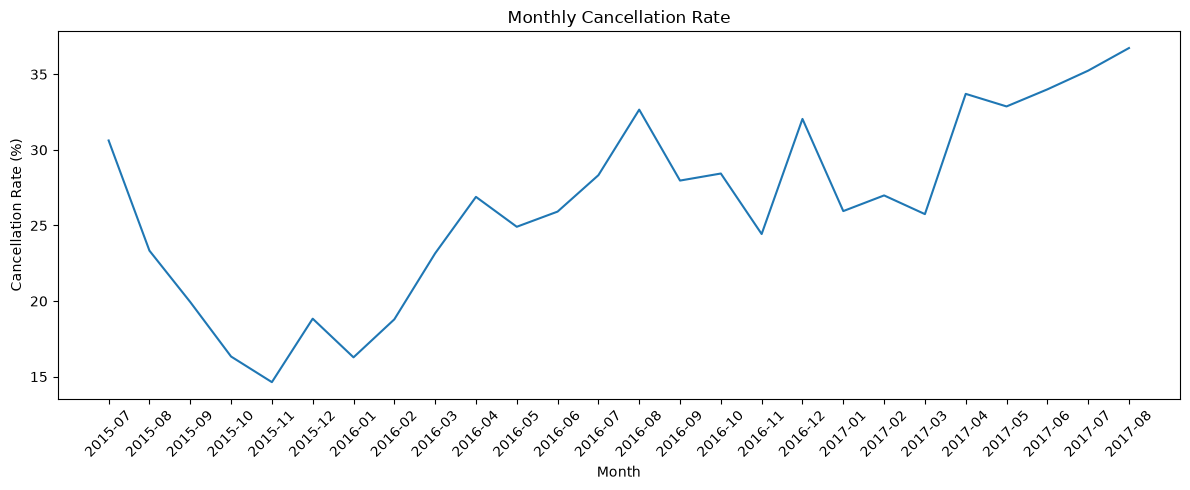

In [64]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_cancellation.index.astype(str),
    monthly_cancellation.values
)

plt.title("Monthly Cancellation Rate")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../image/cancellation_rate_overtime.png", dpi=300, bbox_inches="tight")
plt.show()

In [55]:
print("EDA COMPLETE")
print("-----------------------------")
print("Total bookings:", len(df))
print("Cancellation rate:", round(df["is_canceled"].mean() * 100, 2), "%")
print("Highest hotel cancellation:", hotel_cancellation.idxmax())
print("Highest market segment cancellation:", segment_cancellation.idxmax())
print("Highest deposit type cancellation:", deposit_cancellation.idxmax())

EDA COMPLETE
-----------------------------
Total bookings: 87222
Cancellation rate: 27.53 %
Highest hotel cancellation: City Hotel
Highest market segment cancellation: Undefined
Highest deposit type cancellation: Non Refund
